# **Telangana Groundwater Quality 2018 - 2020 Data Analysis**

Library Imports

In [19]:
import pandas as pd

In [20]:
import numpy as np

In [21]:
import matplotlib.pyplot as plt

In [22]:
import geopandas as gpd

#### Initial Data Load and inspection

In [23]:
data_2018 = pd.read_csv("../Data/ground_water_quality_2018_post.csv")

In [24]:
data_2019 = pd.read_csv("../Data/ground_water_quality_2019_post.csv")

In [25]:
data_2020 = pd.read_csv("../Data/ground_water_quality_2020_post.csv")

In [26]:
print(data_2018.info())
print(data_2019.info())
print(data_2020.info())

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sno               374 non-null    int64  
 1   district          374 non-null    str    
 2   mandal            374 non-null    str    
 3   village           374 non-null    str    
 4   lat_gis           374 non-null    float64
 5   long_gis          374 non-null    float64
 6   gwl               371 non-null    float64
 7   season            374 non-null    str    
 8   pH                374 non-null    float64
 9   E.C               374 non-null    int64  
 10  TDS               374 non-null    float64
 11  CO3               374 non-null    int64  
 12  HCO3              374 non-null    float64
 13  Cl                374 non-null    int64  
 14  F                 374 non-null    float64
 15  NO3               374 non-null    float64
 16  SO4               374 non-null    float64
 17  Na      

In [27]:
print(data_2018.head())
print(data_2019.head())
print(data_2020.head())

   sno  district       mandal      village    lat_gis   long_gis   gwl  \
0    1  ADILABAD     Adilabad     Adilabad  19.668300  78.524700  5.09   
1    2  ADILABAD  Bazarhatnur  Bazarhatnur  19.458888  78.350833  5.10   
2    3  ADILABAD  Gudihatnoor  Gudihatnoor  19.525555  78.512222  4.98   
3    4  ADILABAD      Jainath      Jainath  19.730555  78.640000  5.75   
4    5  ADILABAD      Narnoor      Narnoor  19.495665  78.852654  2.15   

              season    pH   E.C  ...    SO4     Na    K  Ca      Mg  \
0  postmonsoon 2018   8.28   745  ...   46.0   49.0  4.0  48  38.896   
1  postmonsoon 2018   8.29   921  ...   68.0   42.0  5.0  56  63.206   
2  postmonsoon 2018   7.69   510  ...   44.0   45.0  2.0  24  38.896   
3  postmonsoon 2018   8.09   422  ...   35.0   27.0  1.0  32  19.448   
4  postmonsoon 2018   8.21  2321  ...  280.0  298.0  5.0  56  92.378   

          T.H       SAR  Classification  RSC  meq  / L  Classification.1  
0  279.934211  1.273328            C2S1      -1

#### Comparison of column names and identifying differences

In [28]:
col_2018 = set(data_2018.columns)
col_2019 = set(data_2019.columns)
col_2020 = set(data_2020.columns)

In [29]:
all_match = (col_2018 == col_2019 == col_2020)
print(all_match)

False


In [30]:
print("Only in 2018 data", col_2018 - col_2019 - col_2020)
print("Only in 2019 data", col_2019 - col_2020 - col_2018)
print("Only in 2020 data", col_2020 - col_2018 - col_2019)

Only in 2018 data set()
Only in 2019 data {'Mg+2', 'CO_-2 ', 'EC', 'K+', 'F -', 'SO4-2', 'Cl -', 'Na+', 'Ca+2', 'NO3- ', 'HCO_ - '}
Only in 2020 data set()


In [31]:
print(sorted(col_2018))

['CO3', 'Ca', 'Cl', 'Classification', 'Classification.1', 'E.C', 'F', 'HCO3', 'K', 'Mg', 'NO3 ', 'Na', 'RSC  meq  / L', 'SAR', 'SO4', 'T.H', 'TDS', 'district', 'gwl', 'lat_gis', 'long_gis', 'mandal', 'pH', 'season', 'sno', 'village']


In [32]:
print(sorted(col_2019))

['CO_-2 ', 'Ca+2', 'Cl -', 'Classification', 'Classification.1', 'EC', 'F -', 'HCO_ - ', 'K+', 'Mg+2', 'NO3- ', 'Na+', 'RSC  meq  / L', 'SAR', 'SO4-2', 'T.H', 'TDS', 'district', 'gwl', 'lat_gis', 'long_gis', 'mandal', 'pH', 'season', 'sno', 'village']


In [33]:
print(sorted(col_2020))

['CO3', 'Ca', 'Cl', 'Classification', 'Classification.1', 'E.C', 'F', 'HCO3', 'K', 'Mg', 'NO3 ', 'Na', 'RSC  meq  / L', 'SAR', 'SO4', 'T.H', 'TDS', 'district', 'gwl', 'lat_gis', 'long_gis', 'mandal', 'pH', 'season', 'sno', 'village']


In [34]:
data_2019 = data_2019.rename(columns={
    "CO_-2 ": "CO3",
    "Ca+2": "Ca",
    "Cl -": "Cl",
    "EC": "E.C",
    "F -": "F",
    "HCO_ - ": "HCO3",
    "K+": "K",
    "Mg+2": "Mg",
    "NO3- ": "NO3 ",
    "Na+": "Na",
    "SO4-2": "SO4",

})

In [35]:
print(data_2019.columns)

Index(['sno', 'district', 'mandal', 'village', 'lat_gis', 'long_gis', 'gwl',
       'season', 'pH', 'E.C', 'TDS', 'CO3', 'HCO3', 'Cl', 'F', 'NO3 ', 'SO4',
       'Na', 'K', 'Ca', 'Mg', 'T.H', 'SAR', 'Classification', 'RSC  meq  / L',
       'Classification.1'],
      dtype='str')


In [36]:
col_2018 = set(data_2018.columns)
col_2019 = set(data_2019.columns)
col_2020 = set(data_2020.columns)

In [37]:
all_match = (col_2018 == col_2019 == col_2020)
print(all_match)

True


#### Concatenating the 3 datasets together into a single data set

In [38]:

print(data_2018.shape)
print(data_2019.shape)
print(data_2020.shape)

combined_data = pd.concat([data_2018, data_2019, data_2020], ignore_index=True)

print(combined_data.shape)
print(combined_data.info)

(374, 26)
(364, 26)
(368, 26)
(1106, 26)
<bound method DataFrame.info of       sno  district        mandal       village    lat_gis   long_gis   gwl  \
0       1  ADILABAD      Adilabad      Adilabad  19.668300  78.524700  5.09   
1       2  ADILABAD   Bazarhatnur   Bazarhatnur  19.458888  78.350833  5.10   
2       3  ADILABAD   Gudihatnoor   Gudihatnoor  19.525555  78.512222  4.98   
3       4  ADILABAD       Jainath       Jainath  19.730555  78.640000  5.75   
4       5  ADILABAD       Narnoor       Narnoor  19.495665  78.852654  2.15   
...   ...       ...           ...           ...        ...        ...   ...   
1101  375   YADADRI  S.Narayanpur  S.Narayanpur  17.144719  78.860010  9.90   
1102  376   YADADRI   Thurkapally    Gandamalla  17.733101  78.853831  5.74   
1103  377   YADADRI     Valigonda    T. somaram  17.399953  78.952290  1.72   
1104  378   YADADRI     Valigonda   Vemulakonda  17.347782  79.143433  1.65   
1105  379   YADADRI       Y.Gutta    Mallapuram  17.633555

In [ ]:
combined_data.to_csv("../Data/combined_data.csv", index=False)

In [40]:
combined_df = pd.read_csv("../Data/combined_data.csv")

In [41]:
combined_df.isnull().sum()

sno                   0
district              0
mandal                0
village               0
lat_gis               0
long_gis              0
gwl                  11
season                0
pH                    0
E.C                   0
TDS                   0
CO3                 160
HCO3                  0
Cl                    0
F                     0
NO3                   0
SO4                   0
Na                    0
K                     0
Ca                    0
Mg                    0
T.H                   0
SAR                   0
Classification        0
RSC  meq  / L         0
Classification.1      0
dtype: int64

#### Groundwater Classification Frequency Analysis

In [42]:
dataset_classifications = combined_df["Classification"].value_counts()
print(dataset_classifications)

Classification
C3S1    696
C2S1    248
C4S1     87
C4S2     36
C3S2     12
C4S4      7
C3S3      6
C4S3      5
C1S1      3
OG        2
O.G       2
C3S4      1
C2S2      1
Name: count, dtype: int64


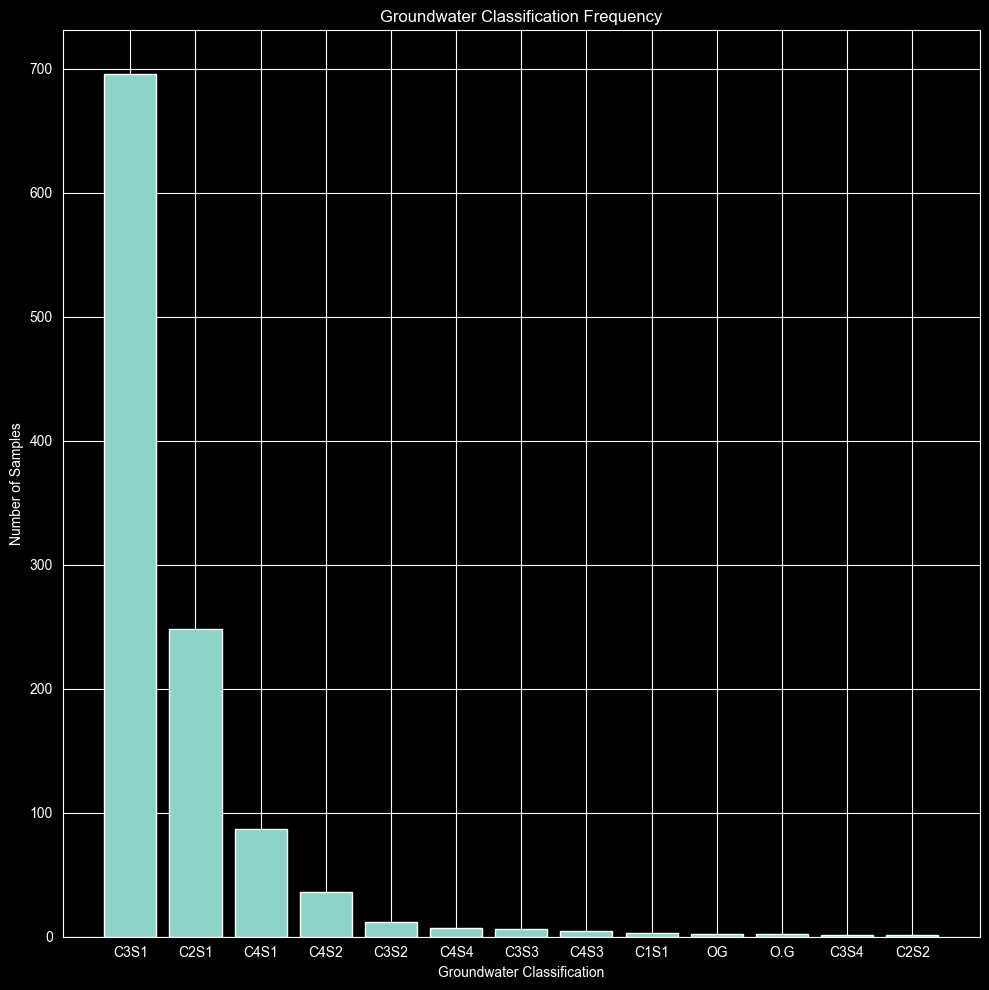

In [68]:
plt.figure(figsize=(10, 10))
plt.bar(dataset_classifications.index, dataset_classifications.values)
plt.xlabel("Groundwater Classification")
plt.ylabel("Number of Samples")
plt.title("Groundwater Classification Frequency")
plt.tight_layout()
plt.savefig("../Figures/Groundwater_Classification_Frequency")
plt.show()


# Regional Groundwater Analysis

In [44]:
#Grouping by district and creating a geodataframe with analytes of interest

gdf = gpd.GeoDataFrame(combined_df, geometry=gpd.points_from_xy(combined_df.long_gis, combined_df.lat_gis), crs="EPSG:4326")

columns = cols = ["gwl", "pH", "E.C", "TDS", "CO3", "HCO3", "NO3 ", "K", "Na", "Ca", "Mg", "Cl", "SO4", "SAR"]

gdf[columns] = gdf[columns].apply(pd.to_numeric, errors="coerce")

district_summary = gdf.groupby("district")[columns].mean().reset_index()



In [45]:
print(district_summary.head())

      district        gwl        pH          E.C         TDS        CO3  \
0     ADILABAD   4.331852  8.010741  1109.148148  709.854815   5.925926   
1    BHADRADRI   5.243636  8.223182  1362.772727  872.174545  17.647059   
2  BHUPALPALLY  13.542500  7.896667   643.916667  412.106667   0.000000   
3    HYDERABAD   6.267391  7.736667  1046.166667  669.546667   5.294118   
4     JAGITYAL   5.162619  7.866190  1070.238095  684.952381   5.476190   

         HCO3        NO3           K          Na         Ca         Mg  \
0  262.962963   68.835906  11.370370  104.481481  48.888889  51.866444   
1  300.959062  119.937421  15.612500  139.147397  47.090909  60.554000   
2  151.666667   40.481731   4.583333   48.583333  38.666667  32.019667   
3  281.737558   57.864885  10.549583   85.079375  84.333333  29.982333   
4  248.571429   37.660880   7.000000  107.904762  59.619048  54.179857   

           Cl        SO4       SAR  
0  121.481481  74.472222  2.443358  
1  173.409091  18.607955  2.99

#### District polygons using Telangana Boundaries Repository data

Index(['OBJECTID', 'STATE_UT', 'STATE_LGD', 'DISTRICT', 'DIST_LGD', 'REMARKS',
       'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='str')


<Axes: >

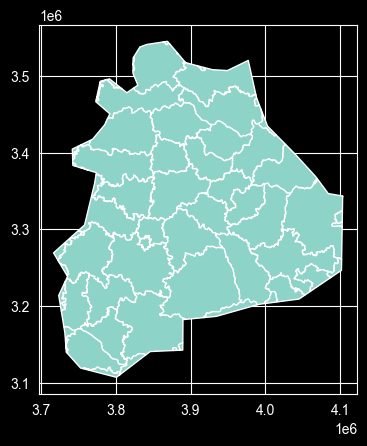

In [46]:
gpkg_districts = gpd.read_file("../Data/District_boundary_Clipped_to_Study_Area.gpkg")
gpkg_districts.to_file("District_boundary.geojson", driver="GeoJSON")

districts = gpd.read_file("District_boundary.geojson")

print(districts.columns)
districts.plot()

In [47]:
print(districts.columns)

Index(['OBJECTID', 'STATE_UT', 'STATE_LGD', 'DISTRICT', 'DIST_LGD', 'REMARKS',
       'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='str')


Comparison of polygon and district summary districts

In [48]:
groundwater_districts = set(district_summary["district"].str.upper())

polygon_districts = set(districts["DISTRICT"].str.upper())

print("In groundwater only:")
print(sorted(groundwater_districts - polygon_districts))

print("\nIn polygons only:")
print(sorted(polygon_districts - groundwater_districts))

In groundwater only:
['BHADRADRI', 'BHUPALPALLY', 'JAGITYAL', 'JOGULAMBA(GADWAL)', 'MAHABUBNAGAR', 'MEDCHAL', 'PEDDAPALLY', 'RANGAREDDY', 'SIRCILLA', 'WARANGAL (R) ', 'WARANGAL (U)', 'YADADRI']

In polygons only:
['ALLURI SITARAMA RAJU', 'BHADRADRI KOTHAGUDEM', 'CHANDRAPUR', 'ELURU', 'GADCHIROLI', 'HANUMAKONDA', 'JAGTIAL', 'JAYASHANKAR BHUPALPALLI', 'JOGULAMBA GADWAL', 'KALABURAGI', 'KURNOOL', 'MAHBUBNAGAR', 'MEDCHAL-MALKAJGIRI', 'NANDED', 'NANDYAL', 'NTR', 'PALNADU', 'PEDDAPALLI', 'PRAKASAM', 'RAICH#R', 'RAJANNA SIRCILLA', 'RANGA REDDY', 'SUKMA', 'WARANGAL', 'Y<DGIR', 'YADADRI BHUVANAGIRI', 'YAVATMAL']


In [49]:
len(groundwater_districts)

33

In [50]:
len(polygon_districts)

48

In [51]:
print(sorted(groundwater_districts))

['ADILABAD', 'BHADRADRI', 'BHUPALPALLY', 'HYDERABAD', 'JAGITYAL', 'JANGAON', 'JOGULAMBA(GADWAL)', 'KAMAREDDY', 'KARIMNAGAR', 'KHAMMAM', 'KUMURAM BHEEM', 'MAHABUBABAD', 'MAHABUBNAGAR', 'MANCHERIAL', 'MEDAK', 'MEDCHAL', 'MULUGU', 'NAGARKURNOOL', 'NALGONDA', 'NARAYANPET', 'NIRMAL', 'NIZAMABAD', 'PEDDAPALLY', 'RANGAREDDY', 'SANGAREDDY', 'SIDDIPET', 'SIRCILLA', 'SURYAPET', 'VIKARABAD', 'WANAPARTHY', 'WARANGAL (R) ', 'WARANGAL (U)', 'YADADRI']


In [52]:
print(sorted(polygon_districts))

['ADILABAD', 'ALLURI SITARAMA RAJU', 'BHADRADRI KOTHAGUDEM', 'CHANDRAPUR', 'ELURU', 'GADCHIROLI', 'HANUMAKONDA', 'HYDERABAD', 'JAGTIAL', 'JANGAON', 'JAYASHANKAR BHUPALPALLI', 'JOGULAMBA GADWAL', 'KALABURAGI', 'KAMAREDDY', 'KARIMNAGAR', 'KHAMMAM', 'KUMURAM BHEEM', 'KURNOOL', 'MAHABUBABAD', 'MAHBUBNAGAR', 'MANCHERIAL', 'MEDAK', 'MEDCHAL-MALKAJGIRI', 'MULUGU', 'NAGARKURNOOL', 'NALGONDA', 'NANDED', 'NANDYAL', 'NARAYANPET', 'NIRMAL', 'NIZAMABAD', 'NTR', 'PALNADU', 'PEDDAPALLI', 'PRAKASAM', 'RAICH#R', 'RAJANNA SIRCILLA', 'RANGA REDDY', 'SANGAREDDY', 'SIDDIPET', 'SUKMA', 'SURYAPET', 'VIKARABAD', 'WANAPARTHY', 'WARANGAL', 'Y<DGIR', 'YADADRI BHUVANAGIRI', 'YAVATMAL']


Matching and filtering out district names not within area of interest/ altering slightly different naming conventions between datasets

In [53]:
outside_sa = {
    'ALLURI SITARAMA RAJU',
    'CHANDRAPUR',
    'ELURU',
    'GADCHIROLI',
    'HANUMAKONDA',
    'KALABURAGI',
    'KURNOOL',
    'NANDED',
    'NANDYAL',
    'NTR',
    'PALNADU',
    'PRAKASAM',
    'RAICH#R',
    'SUKMA',
    'Y<DGIR',
    'YAVATMAL'
}


In [54]:
districts_ts = districts[
    ~districts['DISTRICT'].str.upper().isin(outside_sa)
].copy()

In [55]:
district_map = {
    'BHADRADRI KOTHAGUDEM': 'BHADRADRI',
    'JAGTIAL': 'JAGITYAL',
    'JAYASHANKAR BHUPALPALLI': 'BHUPALPALLY',
    'JOGULAMBA GADWAL': 'JOGULAMBA(GADWAL)',
    'MEDCHAL-MALKAJGIRI': 'MEDCHAL',
    'RANGA REDDY': 'RANGAREDDY',
    'PEDDAPALLI': 'PEDDAPALLY',
    'RAJANNA SIRCILLA': 'SIRCILLA',
    'WARANGAL': 'WARANGAL',
    'YADADRI BHUVANAGIRI': 'YADADRI',
    'MAHBUBNAGAR': 'MAHABUBNAGAR',
}


In [56]:
districts_ts['DISTRICT'] = (
    districts_ts['DISTRICT']
    .str.upper()
    .replace(district_map)
)

In [57]:
groundwater_districts = set(
    district_summary['district'].str.upper()
)

polygon_districts = set(
    districts_ts['DISTRICT']
)

print("Groundwater only:")
print(sorted(groundwater_districts - polygon_districts))

print("\nPolygon only:")
print(sorted(polygon_districts - groundwater_districts))

Groundwater only:
['WARANGAL (R) ', 'WARANGAL (U)']

Polygon only:
['WARANGAL']


In [58]:
print(len(groundwater_districts))

33


In [59]:
print(len(polygon_districts))

32


In [60]:
district_summary["district"] = (
    district_summary["district"]
    .str.strip()
)

district_summary["district"] = district_summary["district"].replace({
    "WARANGAL (R)": "WARANGAL",
    "WARANGAL (U)": "WARANGAL"
})

In [61]:
groundwater_districts = set(
    district_summary['district'].str.upper()
)

polygon_districts = set(
    districts_ts['DISTRICT']
)

print("Groundwater only:")
print(sorted(groundwater_districts - polygon_districts))

print("\nPolygon only:")
print(sorted(polygon_districts - groundwater_districts))

Groundwater only:
[]

Polygon only:
[]


Joining District statistics to District Polygons

In [62]:
combined_district_map = districts_ts.merge(district_summary, left_on='DISTRICT', right_on='district')

Plotting a map of Mean Total Dissolved Solids (mg/L) per District

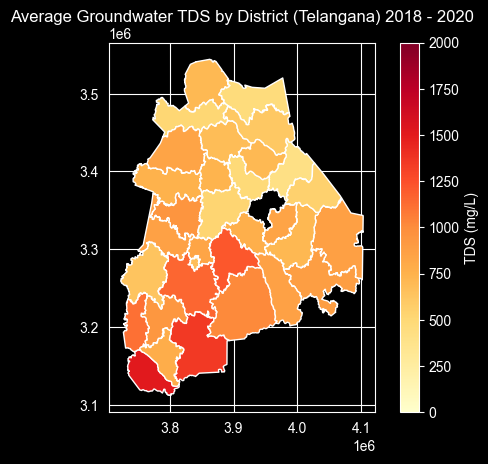

In [69]:
tds_plot = combined_district_map.plot(
    column="TDS",
    legend=True,
    cmap="YlOrRd",
     legend_kwds={
        "label": "TDS (mg/L)",
        "orientation": "vertical"},
    vmin=0,
    vmax=2000
)

tds_plot.set_title(
    "Average Groundwater TDS by"
    " District (Telangana) 2018 - 2020",
    fontsize=12,
    pad=15
)
plt.savefig("../Figures/Mean_TDS_per_District.png")

<Axes: xlabel='district'>

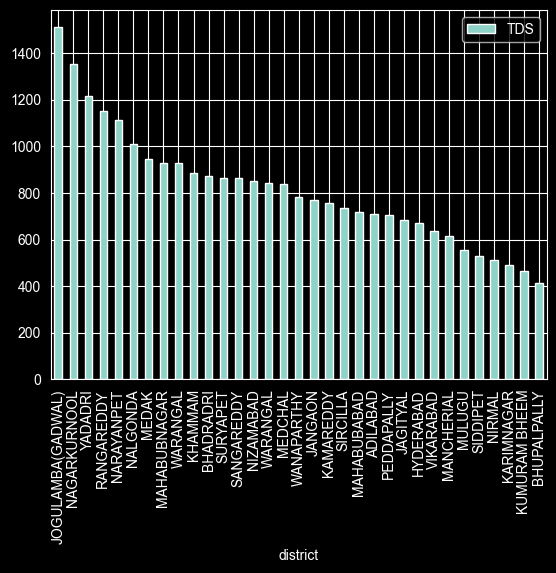

In [64]:
district_summary.sort_values(
    by="TDS",
    ascending=False
).plot.bar(
    x="district",
    y="TDS"
)

Plotting a map of Mean Nitrate Concentration (mg/L) per District

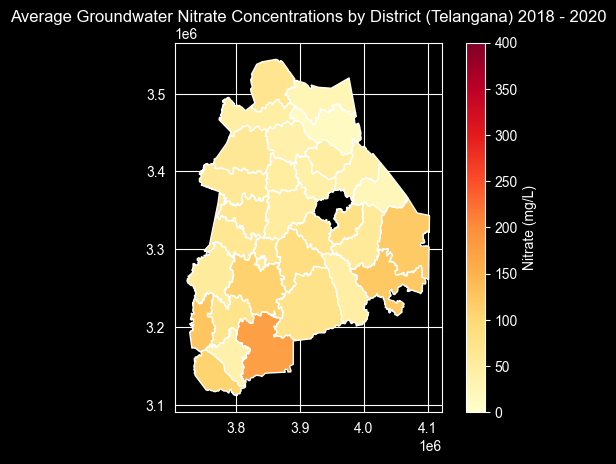

In [70]:
nitrate_plot = combined_district_map.plot(
    column="NO3 ",
    legend=True,
    cmap="YlOrRd",
     legend_kwds={
        "label": "Nitrate (mg/L)",
        "orientation": "vertical"},
    vmin=0,
    vmax=400
)

nitrate_plot.set_title(
    "Average Groundwater Nitrate Concentrations by"
    " District (Telangana) 2018 - 2020",
    fontsize=12,
    pad=15
)
plt.savefig("../Figures/Mean_Nitrate_per_District.png")

<Axes: xlabel='district'>

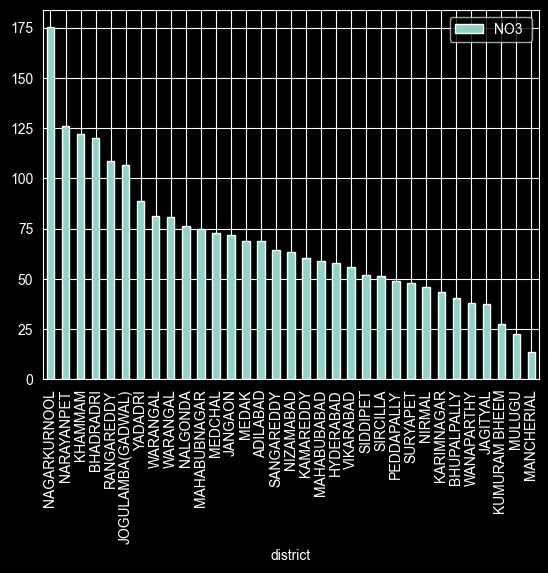

In [66]:
district_summary.sort_values(
    by="NO3 ",
    ascending=False
).plot.bar(
    x="district",
    y="NO3 "
)

### District-Level Groundwater Analysis

In [127]:
chosen_district = "NAGARKURNOOL"

In [128]:
chosen_district_df = gdf[gdf["district"] == chosen_district]

<Axes: >

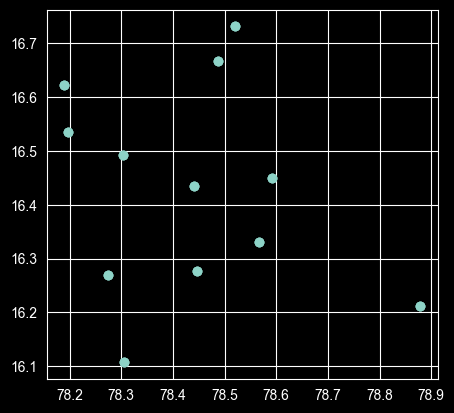

In [130]:
chosen_district_df.plot()

<Axes: >

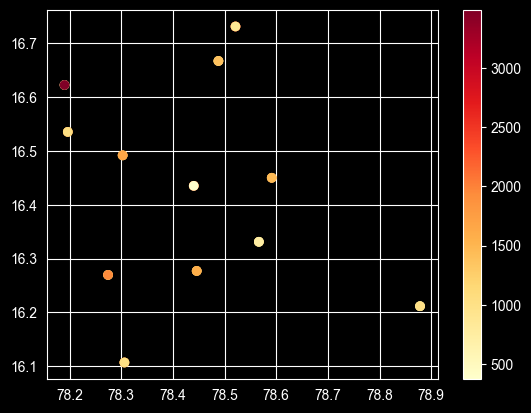

In [131]:
chosen_district_df.plot(
    column="TDS",
    legend=True,
    cmap="YlOrRd"
)

<Axes: >

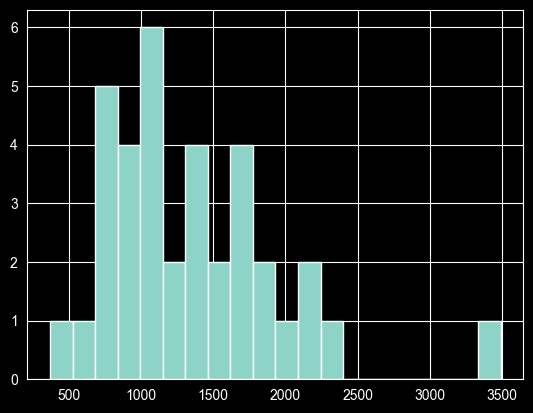

In [136]:
chosen_district_df["TDS"].hist(
    bins=20,
)


<Axes: >

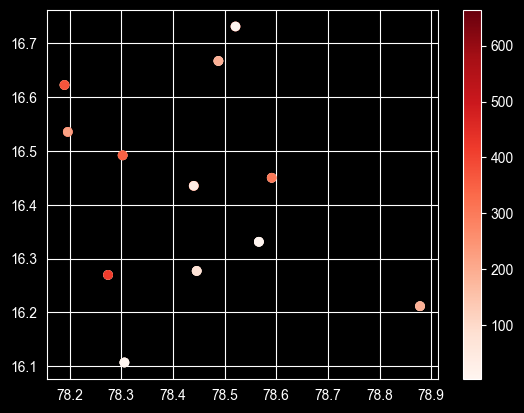

In [132]:
chosen_district_df.plot(
    column="NO3 ",
    legend=True,
    cmap="Reds"
)

<Axes: >

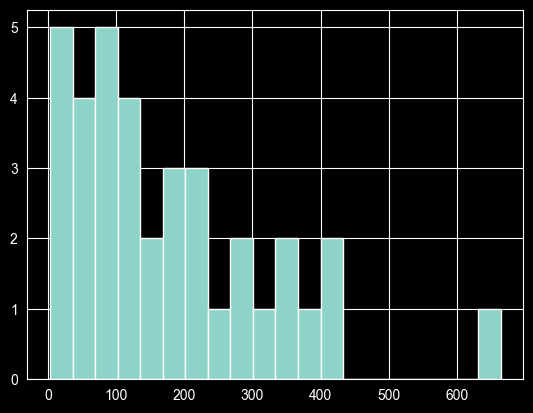

In [137]:
chosen_district_df["NO3 "].hist(
    bins=20,
)

### Plotting nitrate time series data for monitoring locations within Nagarkurnool district (back to original combined dataset)

In [138]:
print(combined_df.columns)

Index(['sno', 'district', 'mandal', 'village', 'lat_gis', 'long_gis', 'gwl',
       'season', 'pH', 'E.C', 'TDS', 'CO3', 'HCO3', 'Cl', 'F', 'NO3 ', 'SO4',
       'Na', 'K', 'Ca', 'Mg', 'T.H', 'SAR', 'Classification', 'RSC  meq  / L',
       'Classification.1'],
      dtype='str')


In [ ]:
# Extracting 'year' from season column and adding to combined data frame

In [140]:
combined_df["year"] = combined_df["season"].str.split().str[-1]

In [142]:
combined_df["year"].head()

0    2018
1    2018
2    2018
3    2018
4    2018
Name: year, dtype: object

In [ ]:
# Getting all SNO (Serial Number) Values of Monitoring locations within district of interest

In [143]:
nagarkurnool_df = combined_df[combined_df["district"] == chosen_district]


In [144]:
monitoring_location_list = nagarkurnool_df["sno"].unique().tolist()

In [145]:
print(monitoring_location_list)

[174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185]


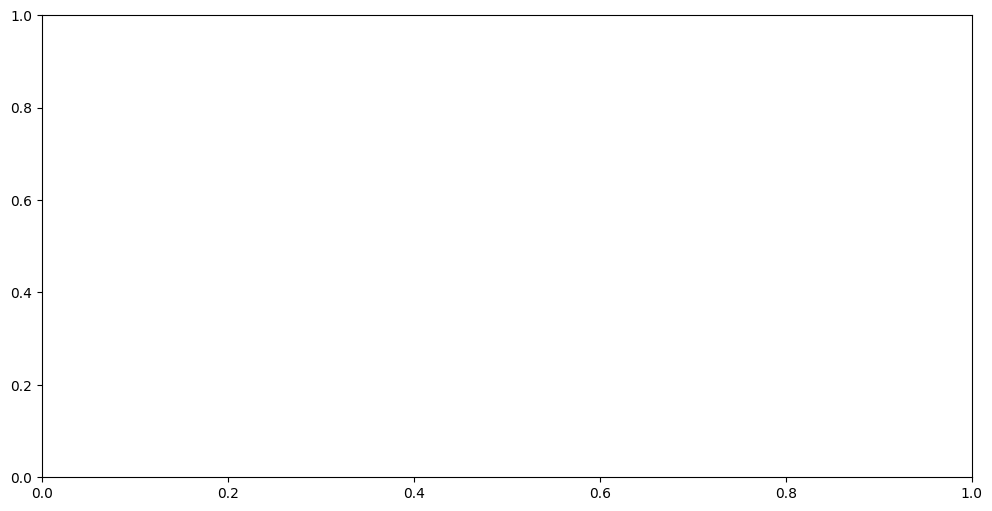

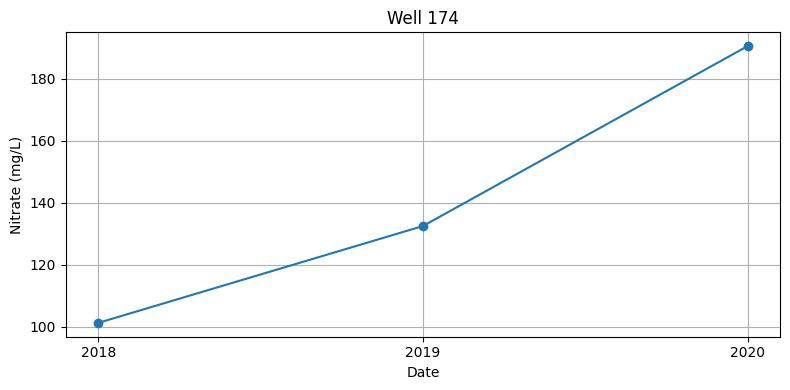

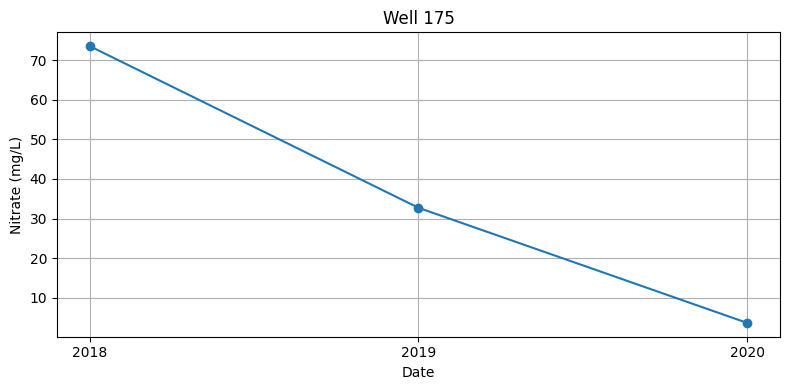

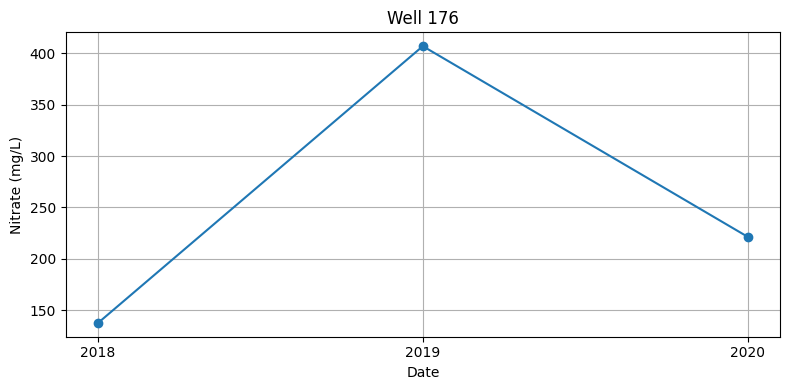

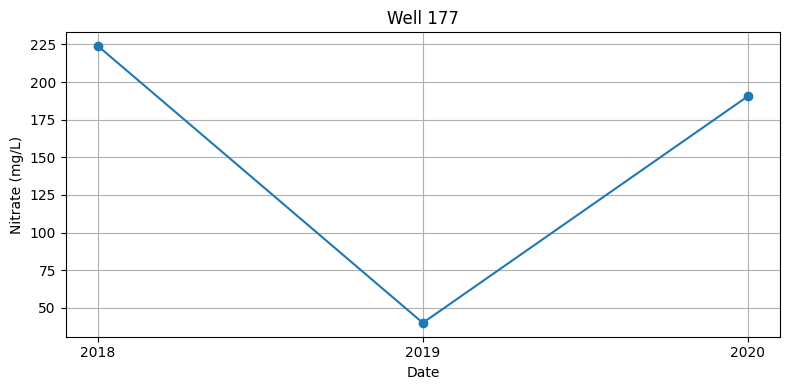

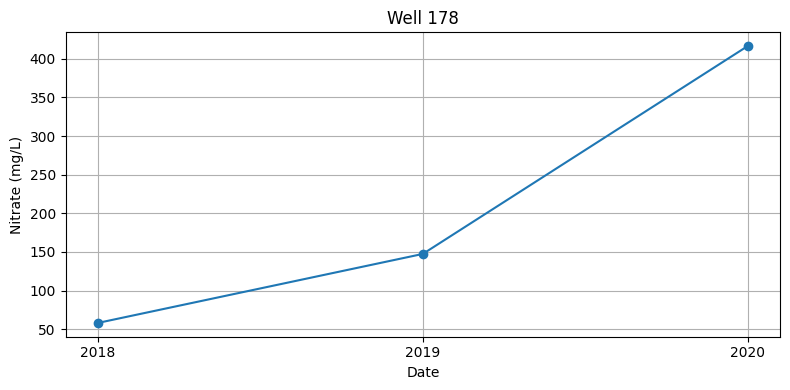

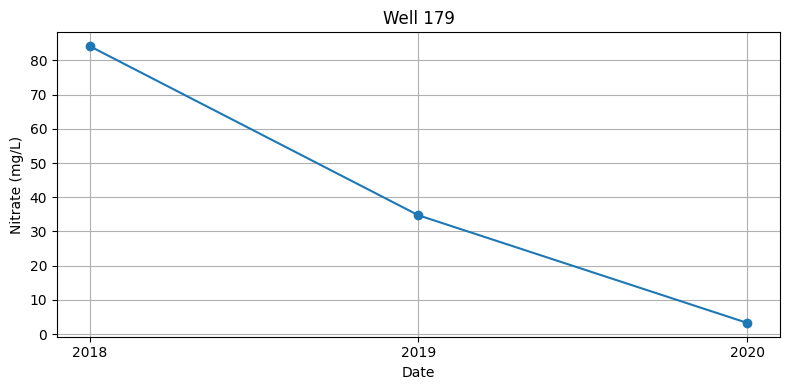

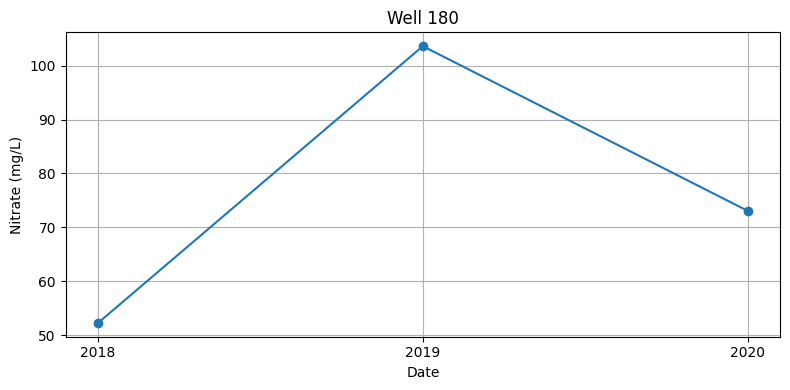

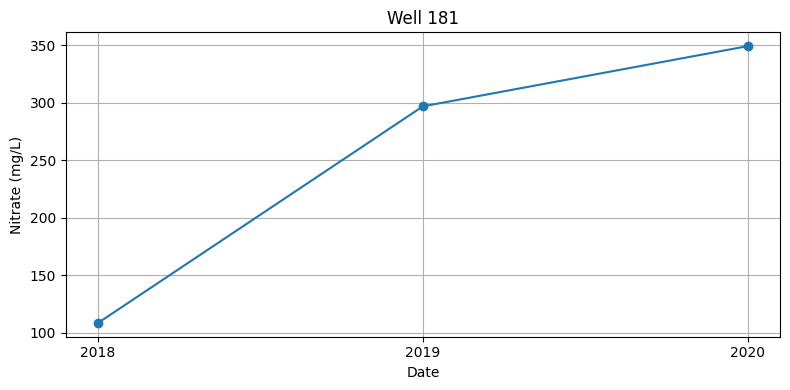

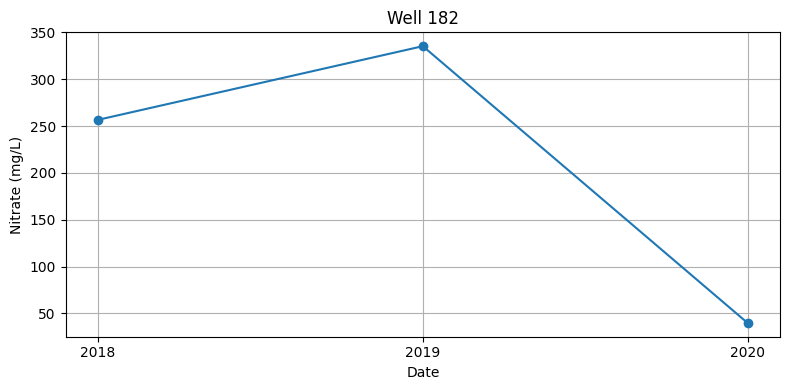

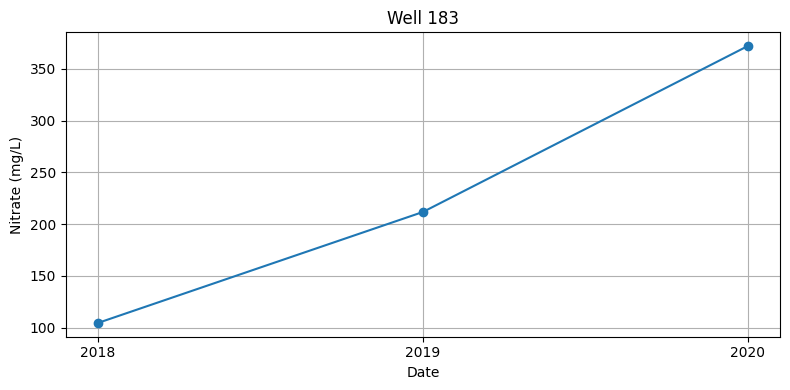

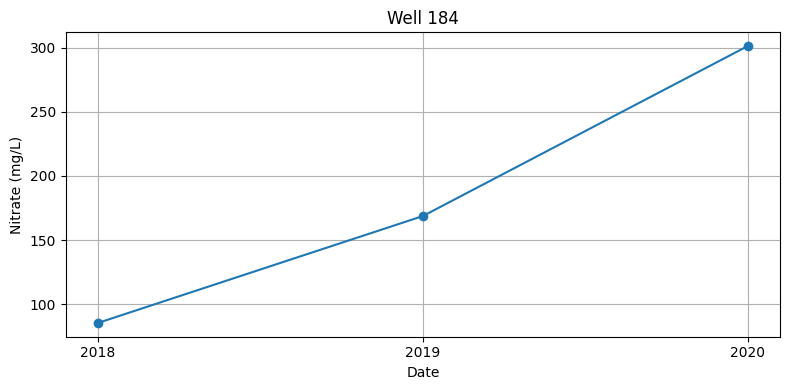

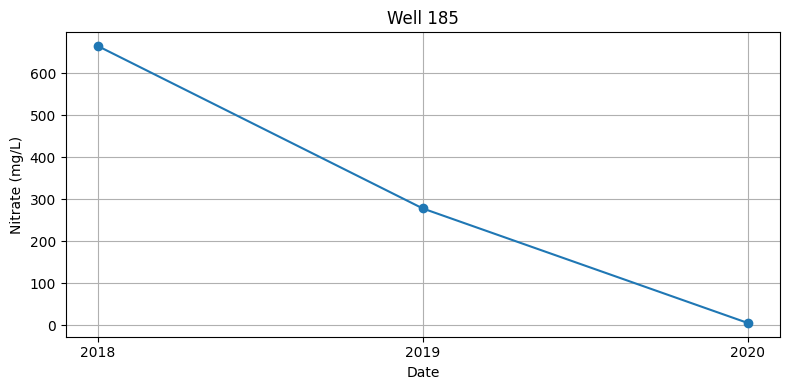

In [157]:
fig, ax = plt.subplots(figsize=(12, 6))

for well in monitoring_location_list:

    well_df = nagarkurnool_df[
        nagarkurnool_df["sno"] == well
    ].sort_values("year")

    plt.figure(figsize=(8,4))
    plt.style.use("default")
    plt.plot(
        well_df["year"],
        well_df["NO3 "],
        marker="o"
    )

    plt.grid(True)


    plt.title(f"Well {well}")
    plt.ylabel("Nitrate (mg/L)")
    plt.xlabel("Date")



    plt.tight_layout()

    plt.savefig(
        f"../Graphs/well_{well}.png",
        dpi=300
    )
    plt.show()
    plt.close()